# 01 — Frame Extraction (Clean)
Extract every **5th** frame to reduce redundancy and keep temporal variety.

## Folder Convention (recommended)

- Input videos: `../data/videos/raw/<category>/<video_name>.mp4`
- Extracted frames: `../data/frames/extracted/<category>/<video_name>/frame_000123.jpg`

> If your paths are different, edit the `VIDEO_ROOT` and `OUT_ROOT` variables.

In [1]:
import os
import cv2

VIDEO_ROOT = r"../data/videos/raw"     
OUT_ROOT   = r"../data/frames/extracted"
STEP       = 5                         

CATEGORIES = ["alligator_cracking", "edge_cracking", "potholes", "transverse_cracking"]

## Helper: extract frames from one video

In [2]:
def extract_every_nth_frame(video_path, out_dir, step=5, prefix="frame"):
    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Could not open:", video_path)
        return 0

    saved = 0
    idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if idx % step == 0:
            fname = f"{prefix}_{idx:06d}.jpg"
            cv2.imwrite(os.path.join(out_dir, fname), frame)
            saved += 1

        idx += 1

    cap.release()
    print(f"Saved {saved} frames → {out_dir}")
    return saved

## Run extraction for all videos in each category

This scans each category folder and extracts frames for every `.mp4` found.

In [3]:
import glob

def extract_category(category):
    cat_in  = os.path.join(VIDEO_ROOT, category)
    cat_out = os.path.join(OUT_ROOT, category)

    videos = sorted(glob.glob(os.path.join(cat_in,"**", "*.mp4")))
    if len(videos) == 0:
        print("No videos found in:", cat_in)
        return

    for vp in videos:
        name = os.path.splitext(os.path.basename(vp))[0]
        out_dir = os.path.join(cat_out, name)
        extract_every_nth_frame(vp, out_dir, step=STEP, prefix=name)

for c in CATEGORIES:
    extract_category(c)

Saved 240 frames → ../data/frames/extracted\alligator_cracking\alligator_cracking_01
Saved 100 frames → ../data/frames/extracted\alligator_cracking\alligator_cracking_02
Saved 104 frames → ../data/frames/extracted\alligator_cracking\alligator_cracking_03
Saved 125 frames → ../data/frames/extracted\edge_cracking\edge_cracking_01
Saved 75 frames → ../data/frames/extracted\edge_cracking\edge_cracking_02
Saved 112 frames → ../data/frames/extracted\edge_cracking\edge_cracking_03
Saved 75 frames → ../data/frames/extracted\potholes\potholes_01
Saved 181 frames → ../data/frames/extracted\potholes\potholes_02
Saved 71 frames → ../data/frames/extracted\potholes\potholes_03
Saved 227 frames → ../data/frames/extracted\potholes\potholes_04
Saved 151 frames → ../data/frames/extracted\transverse_cracking\transverse_cracking_01
Saved 125 frames → ../data/frames/extracted\transverse_cracking\transverse_cracking_02
Saved 94 frames → ../data/frames/extracted\transverse_cracking\transverse_cracking_03


## Quick sanity check (show 1 sample frame)

This is only for verification. If you already trust extraction, you can skip.

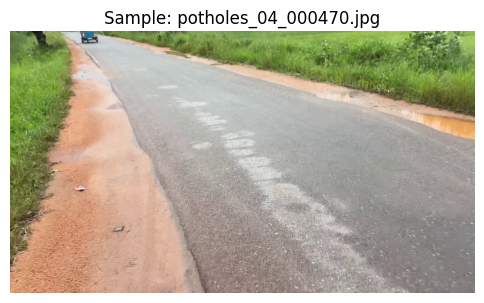

In [4]:
import matplotlib.pyplot as plt
import random

def show_one_sample_frame(category):
    import glob
    paths = glob.glob(os.path.join(OUT_ROOT, category, "*", "*.jpg"))
    if not paths:
        print("No frames found for:", category)
        return
    p = random.choice(paths)
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.title(f"Sample: {os.path.basename(p)}")
    plt.axis("off")
    plt.show()

show_one_sample_frame("potholes")